## IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

2026-05-19 14:20:31.325184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779200431.558197      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779200431.619613      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779200432.185783      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779200432.185818      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779200432.185821      57 computation_placer.cc:177] computation placer alr

## Getting all directory name

In [2]:
os.listdir('/kaggle/input/competitions/birdclef-2026')

['sample_submission.csv',
 'taxonomy.csv',
 'train_audio',
 'train_soundscapes_labels.csv',
 'train_soundscapes',
 'train.csv',
 'recording_location.txt',
 'test_soundscapes']

In [3]:
df_train=pd.read_csv('/kaggle/input/competitions/birdclef-2026/train.csv')

In [4]:
df_train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 4.1+ MB


In [6]:
folders=['sample_submission.csv',
 'taxonomy.csv',
 'train_audio',
 'train_soundscapes_labels.csv',
 'train_soundscapes',
 'train.csv',
 'recording_location.txt',
 'test_soundscapes']

# Testing on one audio file

In [7]:
test_audio='/kaggle/input/competitions/birdclef-2026/train_audio/24279/iNat125223.ogg'

# GETTING NUMPY ARRAY IN DATA FOR VISUALIZING THE SIGNALS USING LIBROSA

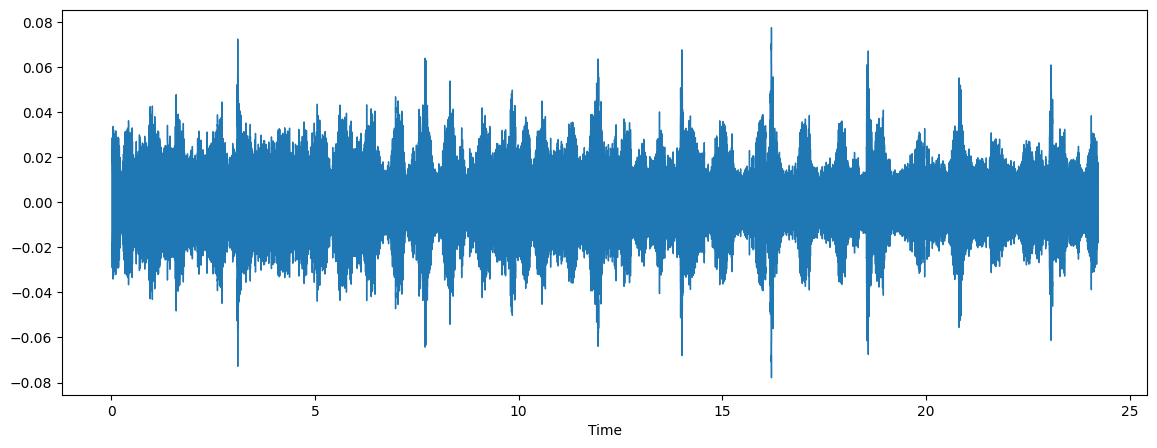

In [31]:
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(test_audio)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(test_audio)

# Spectrogram - Picture of Sound
## STFT- short time fourier transform
1. takes small chunk
2. finds frequencies inside chunk
3. moves slightly forward
4. repeats
``frame_length=320`` Analyze 320 audio samples at one time
``frame_step=32`` Means take 32 samples and then move forward

## After these steps we would have complex number 
### Because Fourier transform stores:
1. magnitude
2. phase
``tensorflow.abs(spectrogram)`` convert complex numbers into magnitude values like ``3+2j = 3.6`` WE GET THIS BY ``abs(3+2j) = sqrt(3² + 2²)``

## At last we expanded the dimension
### Because CNN require height,width,channel 
BEFORE ``(125,123) - > (125,123,1)``

In [9]:
spectrogram=tf.signal.stft(data,frame_length=320,
                                 frame_step=32)
spectrogram=tf.abs(spectrogram)
spectrogram=tf.expand_dims(spectrogram,axis=2)

I0000 00:00:1779200485.829247      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779200485.835650      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Picture of Spectrogram

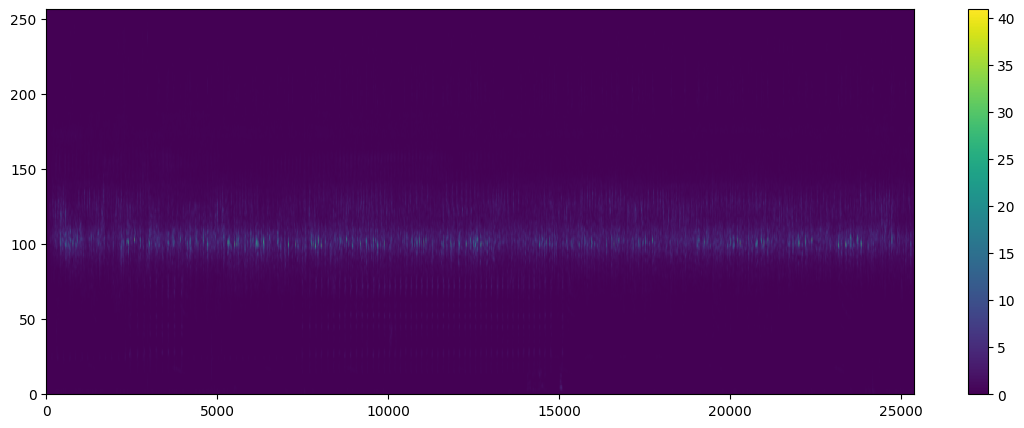

In [78]:
plt.figure(figsize=(14,5))

plt.imshow(
    tf.transpose(spectrogram)[0],
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.show()

# Load the file
### Converting the audio file into signal array

In [76]:
# def load_audio(filename):
#     # if hasattr(filename, 'item'):
#     #     filename = filename.item()
#     data,sample_rate=librosa.load(filename,
#                                   sr=16000,
#                                   mono=True)
#     return data
def load_audio(filename):
    # 1. If it's a TensorFlow tensor, extract its numpy bytes value
    if hasattr(filename, 'numpy'):
        filename = filename.numpy()
        
    # 2. If it's in bytes format (b'/path/...'), decode it to a clean Python string
    if isinstance(filename, bytes):
        filename = filename.decode('utf-8')
        
    # 3. Now librosa can read the clean path string perfectly
    data, sample_rate = librosa.load(filename, sr=16000, mono=True)
    return data

## Preprocesing
1. It takes audio file convert audio to signal array
2. Then it crop first 5 sec of audio and rest is dumpped
3. If the size of audio was less then 5 sec the remaining space is filled with zeros
4. Converting array into spectrogram

In [60]:
# def preprocess(filename,label):
#     data=load_audio(filename)
    
#     if len(data)<16000:
#         spectrogram=tf.zeros([2491,257,1],dtype=tf.float32)
#         return spectrogram,label
        
#     data=data[:80000]
    
#     pad_length = 80000 - tf.shape(data)[0]  # how many zeros needed
#     zero_padding = tf.zeros([pad_length], dtype=tf.float32)
    
#     data=tf.concat([data,zero_padding],0)
#     spectrogram=tf.signal.stft(data,frame_length=320,
#                                  frame_step=32)
    
#     spectrogram=tf.abs(spectrogram)
#     spectrogram=tf.expand_dims(spectrogram,axis=2)

#     return spectrogram,label

def preprocess(filename, label):
    # 1. Safely load audio dynamically inside the TensorFlow graph
    [data,] = tf.py_function(load_audio, [filename], [tf.float32])
    data.set_shape([None]) # Tell TF it's a 1D signal array
    
    # 2. Set target sample window: 5 seconds @ 16kHz = 80,000 samples
    target_samples = 80000
    signal_len = tf.shape(data)[0]
    
    # 3. Uniform pad or clip so EVERY file has an identical shape
    if signal_len < target_samples:
        pad_length = target_samples - signal_len
        zero_padding = tf.zeros([pad_length], dtype=tf.float32)
        data = tf.concat([data, zero_padding], axis=0)
    else:
        data = data[:target_samples]
        
    # 4. Generate the Spectrogram (Output shape: 2491, 257, 1)
    spectrogram = tf.signal.stft(data, frame_length=512, frame_step=64)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=-1) 
    
    return spectrogram, label

In [79]:
df=df_train[['primary_label','filename']]
path='/kaggle/input/competitions/birdclef-2026/train_audio/'
df.loc[:,'filename']=path+df.loc[:,'filename']

### Checking the audio files, max size, min size and mean size for preprocessing

In [13]:
!pip install mutagen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 5.2 MB/s eta 0:00:00a 0:00:01


In [80]:
import os
from concurrent.futures import ThreadPoolExecutor
from mutagen.oggvorbis import OggVorbis

TARGET_SR = 16000  
all_files = df['filename'].tolist()

def get_audio_length(file_path):
    try:
        audio = OggVorbis(file_path)
        # audio.info.length gives duration in seconds
        # Multiply by target sample rate to get the sample length
        return int(audio.info.length * TARGET_SR)
    except Exception as e:
        return 0

# Use multithreading to read headers in parallel
with ThreadPoolExecutor() as executor:
    lengths = list(executor.map(get_audio_length, all_files))

# Filter out any failed reads (0) if necessary
lengths = [l for l in lengths if l > 0]

In [81]:
print(f'MEAN Size of audio : {tf.math.reduce_mean(lengths)/16000} sec')
print(f'MIN Size of audio  : {tf.math.reduce_min(lengths)/16000} sec')
print(f'MAX Size of audio  : {tf.math.reduce_max(lengths)/16000} sec')

MEAN Size of audio : 34.8825625 sec
MIN Size of audio  : 0.008 sec
MAX Size of audio  : 6881.097 sec


In [82]:
df.shape

(35549, 2)

In [83]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
df.loc[:,'primary_label']=labelencoder.fit_transform(df.loc[:,'primary_label'])

In [84]:
X=df['filename']
y=df['primary_label']

In [85]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(f'The shape of x_train is {x_train.shape} and shape of y_train is {y_train.shape}')
print(f'The shape of x_test is {x_test.shape} and shape of y_test is {y_test.shape}')

The shape of x_train is (28439,) and shape of y_train is (28439,)
The shape of x_test is (7110,) and shape of y_test is (7110,)


# dp

In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D

In [59]:
classification_num=len(os.listdir('/kaggle/input/competitions/birdclef-2026/train_audio'))
classification_num

206

In [ ]:
model=Sequential()

model.add(Conv2D(16,(3,3),activation='relu',input_shape=(2491, 257, 1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(16,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(classification_num,activation='softmax'))

In [ ]:
model.summary()

In [ ]:
from tensorflow.keras.metrics import Precision, Recall
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy',Precision(),Recall()])

In [ ]:
import gc
gc.collect()
tf.keras.backend.clear_session()

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,        # stop if no improvement for 3 epochs
    restore_best_weights=True
)

hist = model.fit(train, epochs=20,
                 validation_data=test,
                 callbacks=[callback])